In [2]:
!pip install -q ultralytics

In [3]:
import os
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo


In [5]:
yaml_path = path + "/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'path': '/kaggle/working/D Fire Dataset', 'train': 'data/train/images', 'val': 'data/val/images', 'test': 'data/test/images', 'names': ['smoke', 'fire'], 'nc': 2, 'train_count': 14122, 'val_count': 3099, 'test_count': 4306}


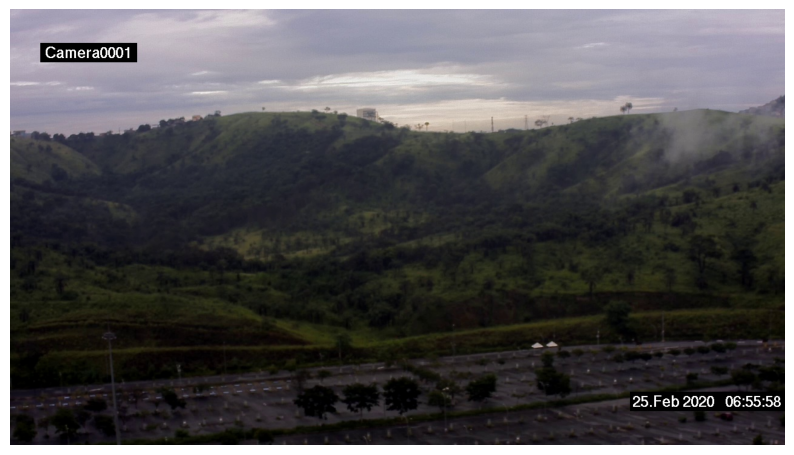

In [6]:
image_dir = path + "/data/train/images"
label_dir = path + "/data/train/labels"

image_files = os.listdir(image_dir)

image_name = random.choice(image_files)

image_path = os.path.join(image_dir, image_name)
label_name = os.path.splitext(image_name)[0] + ".txt"
label_path = os.path.join(label_dir, label_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h,w,_ = image.shape

with open(label_path, "r") as f:
    labels = f.readlines()

for label in labels:
    cls, x,y,bw,bh = map(float, label.split())

    x1 = int((x-bw/2)*w)
    y1 = int((y-bh/2)*h)
    x2 = int((x+bw/2)*w)
    y2 = int((y+bh/2)*h)

    color = (255,0,0) if int(cls) == 0 else (0,255,0)

    class_name = data["names"][int(cls)]

    cv2.rectangle(image,(x1,y1), (x2,y2), color,2)
    cv2.putText(
        image,
        class_name,
        (x1,y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
    )

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [7]:
from collections import Counter

class_counter = Counter()

total_images = 0
label_dir = path + "/data/train/labels"


for label_file in os.listdir(label_dir):
    total_images += 1
    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:
        cls = int(label.split()[0])
        class_counter[data["names"][cls]] += 1

print("Total Images :", total_images)
print(class_counter)

Total Images : 14122
Counter({'fire': 9638, 'smoke': 7794})


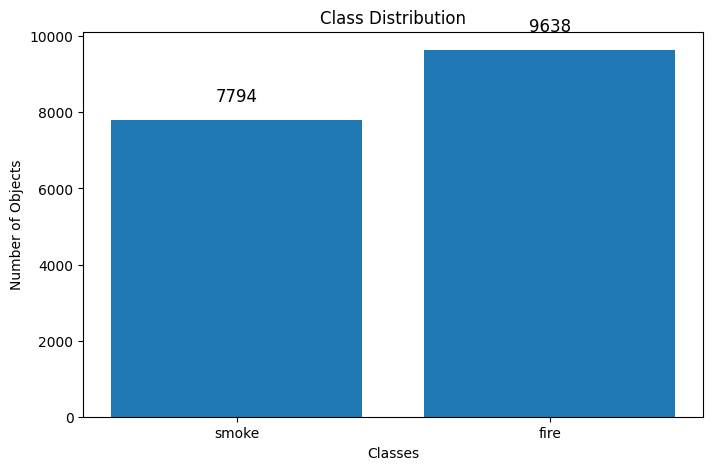

In [8]:
import matplotlib.pyplot as plt

classes = list(class_counter.keys())
counts = list(class_counter.values())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Objects")

# Add numbers on top of bars
for i, count in enumerate(counts):
    plt.text(i, count + 500, str(count), ha="center", fontsize=12)

plt.show()

In [9]:
image_sizes = []

for image_file in image_files:

    image_path = os.path.join(image_dir, image_file)

    image = cv2.imread(image_path)

    h, w = image.shape[:2]

    image_sizes.append((w, h))

print("Total Images:", len(image_sizes))

print("First 10 image sizes:")

for size in image_sizes[:10]:
    print(size)

Total Images: 14122
First 10 image sizes:
(540, 360)
(842, 595)
(1499, 725)
(1280, 720)
(1423, 755)
(800, 446)
(640, 360)
(1280, 720)
(1280, 720)
(640, 360)


In [10]:
from collections import Counter

resolution_counter = Counter(image_sizes)

print("Top 10 Most Common Resolutions:\n")

for resolution, count in resolution_counter.most_common(10):
    print(f"{resolution} : {count}")

Top 10 Most Common Resolutions:

(1280, 720) : 6062
(640, 360) : 2724
(480, 360) : 476
(640, 352) : 442
(1920, 1080) : 178
(540, 360) : 158
(768, 432) : 99
(800, 450) : 86
(640, 480) : 81
(198, 360) : 76


In [11]:
box_widths = []
box_heights = []

for label_file in os.listdir(label_dir):

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:

        cls, x, y, bw, bh = map(float, label.split())

        box_widths.append(bw)
        box_heights.append(bh)

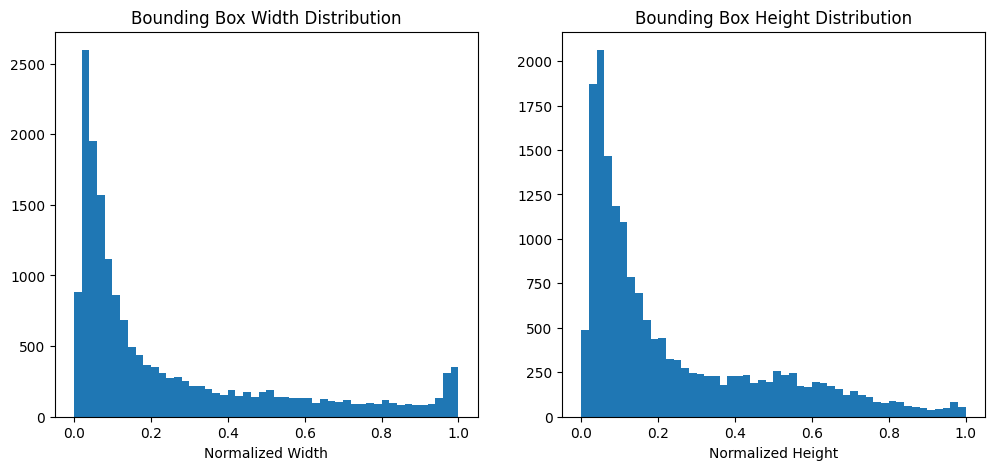

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(box_widths, bins=50)
plt.title("Bounding Box Width Distribution")
plt.xlabel("Normalized Width")

plt.subplot(1,2,2)
plt.hist(box_heights, bins=50)
plt.title("Bounding Box Height Distribution")
plt.xlabel("Normalized Height")

plt.show()

In [13]:
model = YOLO("yolo11s.pt")

In [14]:
with open(path + "/data.yaml", "r") as f:
    print(yaml.safe_load(f))

{'path': '/kaggle/working/D Fire Dataset', 'train': 'data/train/images', 'val': 'data/val/images', 'test': 'data/test/images', 'names': ['smoke', 'fire'], 'nc': 2, 'train_count': 14122, 'val_count': 3099, 'test_count': 4306}


In [15]:
# Correct dataset path
dataset_root = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo"

# Read yaml
with open(dataset_root + "/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

# Update the path
data_yaml["path"] = dataset_root

# Save a new yaml inside /kaggle/working
with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(data_yaml)

{'path': '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo', 'train': 'data/train/images', 'val': 'data/val/images', 'test': 'data/test/images', 'names': ['smoke', 'fire'], 'nc': 2, 'train_count': 14122, 'val_count': 3099, 'test_count': 4306}


In [16]:
model.info()

YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs


(181, 9458752, 0, 21.718374400000002)

In [17]:
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=100,
    patience=15,
    imgsz=600,          # Keep for accuracy
    batch=16,           # Try 48, then 64 if it fits
    workers=8,
    cache=True,
    device=0,
    pretrained=True,
    save_period=10,
    optimizer="auto",
    amp=True,
    seed=42
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=600, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [19]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.8 MB/s eta 0:00:00a 0:00:01


In [3]:
!pip install -q ultralytics yt-dlp

In [8]:
import os
import glob
import yt_dlp
from ultralytics import YOLO
import cv2

# ============================================
# DOWNLOAD YOUTUBE VIDEO
# ============================================

youtube_url = input("Enter YouTube URL: ")

# Delete previous downloaded videos
for file in glob.glob("youtube_video*"):
    os.remove(file)

# ydl_opts = {
#     "format": "bestvideo+bestaudio/best",
#     "merge_output_format": "mp4",
#     "outtmpl": "youtube_video.%(ext)s",
#     "quiet": False
# }

ydl_opts = {
    "format": "best[ext=mp4]",
    "outtmpl": "youtube_video.%(ext)s",
    "quiet": False
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([youtube_url])

# Find downloaded file
video_files = glob.glob("youtube_video.*")

if len(video_files) == 0:
    raise FileNotFoundError("Video was not downloaded.")

video_path = video_files[0]

print(f"\n✅ Downloaded: {video_path}")

# ============================================
# LOAD MODEL
# ============================================

MODEL_PATH = "best.pt"      # Put best.pt in the same folder

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("best.pt not found.")

model = YOLO(MODEL_PATH)

# ============================================
# RUN YOLO
# ============================================

results = model.predict(
    source=video_path,
    save=True,
    project="runs",
    name="fire_detection",
    exist_ok=True,
    conf=0.30,
    iou=0.50,
    line_width=3,
    show_labels=True,
    show_conf=True,
    verbose=False
)

print("\n✅ Detection Completed")

# ============================================
# FIND OUTPUT VIDEO
# ============================================

output_folder = str(results[0].save_dir)

output_video = glob.glob(os.path.join(output_folder, "*.mp4"))

if len(output_video) == 0:
    raise Exception("Output video not found.")

output_video = output_video[0]

print(f"\n✅ Saved at:\n{output_video}")

# ============================================
# PLAY VIDEO
# ============================================

cap = cv2.VideoCapture(output_video)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Fire Detection", frame)

    key = cv2.waitKey(25)

    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("\nDone.")

Enter YouTube URL:  https://youtu.be/_RiopkbtPZQ?si=CgdIoYse70cwyBPh


[youtube] Extracting URL: https://youtu.be/_RiopkbtPZQ?si=CgdIoYse70cwyBPh
[youtube] _RiopkbtPZQ: Downloading webpage


[youtube] _RiopkbtPZQ: Downloading android vr player API JSON
[info] _RiopkbtPZQ: Downloading 1 format(s): 18
[download] Destination: youtube_video.mp4
[download] 100% of    9.93MiB in 00:00:03 at 2.81MiB/s     

✅ Downloaded: youtube_video.mp4
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /home/punit/fireGaurd_ai/runs/detect/runs/fire_detection

✅ Detection Completed


Exception: Output video not found.